In [1]:
'''from src.anomaly.lstm_autoencoder import LSTMAutoencoder

model = LSTMAutoencoder(
    n_features=3
)

print(model)'''

'from src.anomaly.lstm_autoencoder import LSTMAutoencoder\n\nmodel = LSTMAutoencoder(\n    n_features=3\n)\n\nprint(model)'

In [2]:
import sys
sys.path.append("..")

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

import matplotlib.pyplot as plt

from src.anomaly.sequence_dataset import create_sequences
from src.anomaly.lstm_autoencoder import LSTMAutoencoder

## Load KITTI sequences 0009 and 0051

We train the LSTM autoencoder on clean data from **both** drives so it learns
a normal-motion prior that generalizes across sequences instead of overfitting
to a single drive.

In [3]:
import pykitti
from pathlib import Path

base = Path.home() / "SensorTrust" / "datasets" / "kitti"

DRIVES = ["0009", "0051"]

kitti_data = {}

for drive in DRIVES:
    kitti_data[drive] = pykitti.raw(
        base_path=str(base),
        date="2011_09_26",
        drive=drive
    )
    print(f"Drive {drive}: {len(kitti_data[drive].oxts)} oxts frames")

Drive 0009: 447 oxts frames
Drive 0051: 438 oxts frames


In [4]:
from src.proxies.lidar_proxy import extract_all_lidar_proxies
from src.proxies.camera_proxy import extract_all_camera_proxies
from src.proxies.imu_proxy import extract_all_imu_proxies
from src.proxies.gps_proxy import extract_all_gps_proxies

# extract clean proxies separately per drive (kept separate so we never
# window across a sequence boundary later on)
drive_proxies = {}

for drive in DRIVES:

    data = kitti_data[drive]

    gps_clean = extract_all_gps_proxies(data.oxts, dt=0.1035)

    imu_clean = extract_all_imu_proxies(
        data.oxts,
        dt=0.1035
    )

    camera_frames = [np.array(f) for f in list(data.cam2)]

    camera_clean = extract_all_camera_proxies(
        camera_frames
    )

    velo_scans = list(data.velo)

    lidar_clean = extract_all_lidar_proxies(
        velo_scans,
        data.oxts[:len(velo_scans)]
    )

    drive_proxies[drive] = {
        "gps": gps_clean,
        "imu": imu_clean,
        "camera": camera_clean,
        "lidar": lidar_clean,
    }

    print(f"Drive {drive}: extracted gps/imu/camera/lidar proxies")

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.
Processing scan 20/443
Processing scan 40/443
Processing scan 60/443
Processing scan 80/443
Processing scan 100/443
Processing scan 120/443
Processing scan 140/443
Processing scan 160/443
Processing scan 180/443
Processing scan 200/443
Processing scan 220/443
Processing scan 240/443
Processing scan 260/443
Processing scan 280/443
Processing scan 300/443
Processing scan 320/443
Processing scan 340/443
Processing scan 360/443
Processing scan 380/443
Processing scan 400/443
Processing scan 420/443
Processing scan 440/443
Drive 0009: extracted gps/imu/camera/lidar proxies
Processing scan 20/438
Processing scan 40/438
Processing scan 60/438
Processing scan 80/438
Processing scan 100/438
Processing scan 120/438
Processing scan 140/438
Processing scan 160/438
Processing scan 180/438
Processing scan 200/438
Processing scan 220/

## Fit the normalizer jointly across both drives

The `MotionNormalizer` needs to see the combined statistics of 0009 + 0051 so
the z-scoring is consistent across both sequences (otherwise features from
one drive could sit on a different scale than the other).

In [5]:
from src.features.gmis import compute_gmis
from src.features.f2_scene import compute_f2
from src.features.normalization import MotionNormalizer
from src.features.f1_kinematic import extract_all_f1_features


def concat_proxy_dicts(dict_list):
    """Concatenate a list of proxy dicts (same keys, numpy array values)
    along axis 0, so the normalizer can fit on combined statistics."""
    keys = dict_list[0].keys()
    combined = {}
    for k in keys:
        combined[k] = np.concatenate(
            [d[k] for d in dict_list],
            axis=0
        )
    return combined


gps_combined = concat_proxy_dicts(
    [drive_proxies[d]["gps"] for d in DRIVES]
)
imu_combined = concat_proxy_dicts(
    [drive_proxies[d]["imu"] for d in DRIVES]
)
camera_combined = concat_proxy_dicts(
    [drive_proxies[d]["camera"] for d in DRIVES]
)
lidar_combined = concat_proxy_dicts(
    [drive_proxies[d]["lidar"] for d in DRIVES]
)

normalizer = MotionNormalizer()

normalizer.fit(
    gps_combined,
    imu_combined,
    camera_combined,
    lidar_combined
)

print("Normalizer fit on combined 0009 + 0051 statistics")

Normalization parameters fitted:
  gps_delta_v         : μ= -0.0786, σ=  0.4652
  gps_heading_rate    : μ=  0.1030, σ=  2.3436
  imu_delta_v         : μ= -0.1440, σ=  0.4784
  imu_yaw_rate        : μ=  0.0054, σ=  0.0800
  camera_flow         : μ=  9.5621, σ=  5.4723
  lidar_icp           : μ=  0.1163, σ=  0.0431
Normalizer fit on combined 0009 + 0051 statistics


## Build features + sequences per drive, then combine

Each drive is transformed and turned into F1 / F2 / GMIS features
**independently**, and `create_sequences` is applied per-drive. Only after
windowing do we concatenate the resulting sequence arrays — this guarantees
no LSTM training window spans the 0009 -> 0051 boundary.

In [6]:
SEQ_LEN = 200

X_clean_per_drive = {}
X_seq_list = []

for drive in DRIVES:

    gps_clean = drive_proxies[drive]["gps"]
    imu_clean = drive_proxies[drive]["imu"]
    camera_clean = drive_proxies[drive]["camera"]
    lidar_clean = drive_proxies[drive]["lidar"]

    z_clean = normalizer.transform(
        gps_clean,
        imu_clean,
        camera_clean,
        lidar_clean
    )

    f1_clean = extract_all_f1_features(
        z=z_clean,
        gps_speed=gps_clean["speed"]
    )["f1"]

    min_len = min(
        len(z_clean["gps_delta_v"]),
        len(z_clean["lidar_icp"])
    )

    f2_clean = compute_f2(
        z_clean["gps_delta_v"][:min_len],
        z_clean["lidar_icp"][:min_len]
    )

    min_len = min(
        len(z_clean["gps_delta_v"]),
        len(z_clean["imu_delta_v"]),
        len(z_clean["lidar_icp"]),
        len(z_clean["camera_flow"])
    )

    gmis_clean = compute_gmis(
        z_clean["gps_delta_v"][:min_len],
        z_clean["imu_delta_v"][:min_len],
        z_clean["lidar_icp"][:min_len],
        z_clean["camera_flow"][:min_len]
    )

    min_len = min(
        len(f1_clean),
        len(f2_clean),
        len(gmis_clean)
    )

    X_clean_drive = np.column_stack([
        f1_clean[:min_len],
        f2_clean[:min_len],
        gmis_clean[:min_len]
    ])

    X_clean_drive = X_clean_drive[
        ~np.isnan(X_clean_drive).any(axis=1)
    ]

    print(f"Drive {drive}: X_clean shape = {X_clean_drive.shape}")

    X_clean_per_drive[drive] = X_clean_drive

    X_seq_drive = create_sequences(
        X_clean_drive,
        seq_len=SEQ_LEN
    )

    print(f"Drive {drive}: X_seq shape  = {X_seq_drive.shape}")

    X_seq_list.append(X_seq_drive)

X_seq = np.concatenate(X_seq_list, axis=0)

print("\nCombined X_seq shape (0009 + 0051):", X_seq.shape)

Drive 0009: X_clean shape = (437, 3)
Drive 0009: X_seq shape  = (238, 200, 3)
Drive 0051: X_clean shape = (432, 3)
Drive 0051: X_seq shape  = (233, 200, 3)

Combined X_seq shape (0009 + 0051): (471, 200, 3)


In [7]:
X_tensor = torch.tensor(
    X_seq,
    dtype=torch.float32
)

dataset = TensorDataset(
    X_tensor,
    X_tensor
)

loader = DataLoader(
    dataset,
    batch_size=32,
    shuffle=True
)

print(len(loader))

15


In [8]:
'''create model'''
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = LSTMAutoencoder(
    n_features=3,
    hidden_size=64,
    latent_size=32
).to(device)

print(device)
print(model)

cpu
LSTMAutoencoder(
  (encoder): LSTM(3, 64, batch_first=True)
  (latent): Linear(in_features=64, out_features=32, bias=True)
  (expand): Linear(in_features=32, out_features=64, bias=True)
  (decoder): LSTM(64, 3, batch_first=True)
)


In [9]:
'''loss + optimizer'''
criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=5e-4
)

In [10]:
'''training loop'''
EPOCHS = 150

losses = []

for epoch in range(EPOCHS):

    model.train()

    epoch_loss = 0

    for batch_x, _ in loader:

        batch_x = batch_x.to(device)

        optimizer.zero_grad()

        reconstructed = model(batch_x)

        loss = criterion(
            reconstructed,
            batch_x
        )

        loss.backward()

        optimizer.step()

        epoch_loss += loss.item()

    epoch_loss /= len(loader)

    losses.append(epoch_loss)

    print(
        f"Epoch {epoch+1:03d}/{EPOCHS} | "
        f"Loss = {epoch_loss:.6f}"
    )

Epoch 001/150 | Loss = 1.261188
Epoch 002/150 | Loss = 0.968437
Epoch 003/150 | Loss = 0.785438
Epoch 004/150 | Loss = 0.746251
Epoch 005/150 | Loss = 0.746912
Epoch 006/150 | Loss = 0.744320
Epoch 007/150 | Loss = 0.735628
Epoch 008/150 | Loss = 0.721898
Epoch 009/150 | Loss = 0.731000
Epoch 010/150 | Loss = 0.750975
Epoch 011/150 | Loss = 0.746516
Epoch 012/150 | Loss = 0.742726
Epoch 013/150 | Loss = 0.738895
Epoch 014/150 | Loss = 0.732922
Epoch 015/150 | Loss = 0.729312
Epoch 016/150 | Loss = 0.727784
Epoch 017/150 | Loss = 0.721053
Epoch 018/150 | Loss = 0.719579
Epoch 019/150 | Loss = 0.710375
Epoch 020/150 | Loss = 0.708048
Epoch 021/150 | Loss = 0.706820
Epoch 022/150 | Loss = 0.703969
Epoch 023/150 | Loss = 0.703374
Epoch 024/150 | Loss = 0.702403
Epoch 025/150 | Loss = 0.703952
Epoch 026/150 | Loss = 0.704033
Epoch 027/150 | Loss = 0.701488
Epoch 028/150 | Loss = 0.702853
Epoch 029/150 | Loss = 0.700849
Epoch 030/150 | Loss = 0.698802
Epoch 031/150 | Loss = 0.700431
Epoch 03

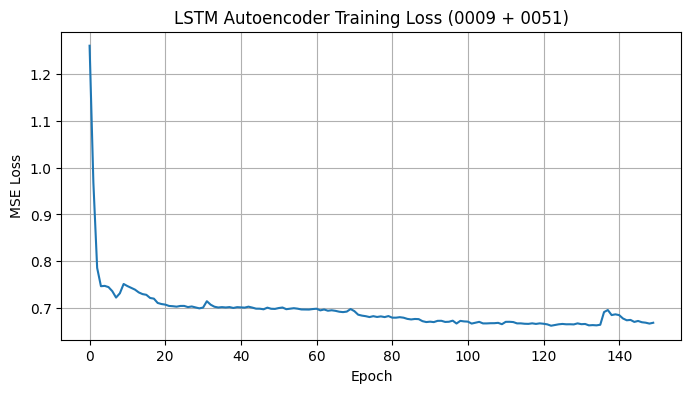

In [11]:
'''plot training loss'''
plt.figure(figsize=(8,4))

plt.plot(losses)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("LSTM Autoencoder Training Loss (0009 + 0051)")

plt.grid(True)
plt.show()

In [12]:
for drive in DRIVES:
    print(drive, X_clean_per_drive[drive].shape)

print("Combined X_seq:", X_seq.shape)

0009 (437, 3)
0051 (432, 3)
Combined X_seq: (471, 200, 3)


In [13]:
from pathlib import Path

MODEL_PATH = Path("../src/models/lstm_autoencoder_09_51.pt")

torch.save(
    model.state_dict(),
    MODEL_PATH
)

print("Saved to:", MODEL_PATH.resolve())

Saved to: C:\Users\disha\SensorTrust\src\models\lstm_autoencoder_09_51.pt


RECONSTRUCTION ERROR ON CLEAN DATA (0009 + 0051 combined)

In [14]:
model.eval()

errors = []

with torch.no_grad():

    for batch_x, _ in loader:

        batch_x = batch_x.to(device)

        reconstructed = model(batch_x)

        mse = torch.mean(
            (batch_x - reconstructed) ** 2,
            dim=(1, 2)
        )

        errors.extend(
            mse.cpu().numpy()
        )

errors = np.array(errors)

print("Mean Error :", np.mean(errors))
print("Std Error  :", np.std(errors))
print("Min Error  :", np.min(errors))
print("Max Error  :", np.max(errors))

Mean Error : 0.6677412
Std Error  : 0.36217824
Min Error  : 0.26787853
Max Error  : 1.201401


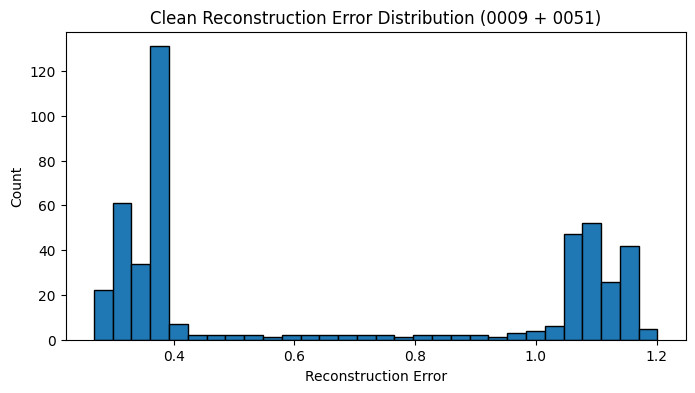

In [15]:
plt.figure(figsize=(8,4))

plt.hist(
    errors,
    bins=30,
    edgecolor="black"
)

plt.title("Clean Reconstruction Error Distribution (0009 + 0051)")
plt.xlabel("Reconstruction Error")
plt.ylabel("Count")

plt.show()

In [16]:
threshold = (
    np.mean(errors)
    + 3 * np.std(errors)
)

print("Anomaly Threshold:", threshold)

Anomaly Threshold: 1.7542759


In [17]:
import json

with open(
    "../src/models/threshold_09_51.json",
    "w"
) as f:

    json.dump(
        {
            "threshold": float(threshold),
            "trained_on": DRIVES
        },
        f,
        indent=4
    )

print("Threshold saved.")

Threshold saved.


In [18]:
np.sum(errors > threshold)

np.int64(0)

In [19]:
len(errors)

471

In [20]:
print("Threshold:", threshold)

print(
    "Clean FP:",
    np.sum(errors > threshold)
)

print(
    "Total Clean:",
    len(errors)
)

print(
    "FPR:",
    100 * np.sum(errors > threshold) / len(errors)
)

Threshold: 1.7542759
Clean FP: 0
Total Clean: 471
FPR: 0.0
